In [1]:
# Combine Time-Dependence and SimpleDiff

import numpy as np
import pandas as pd
from scipy.optimize import minimize
from sympy import *
import matplotlib.pyplot as plt
init_printing(use_latex=true)
filename = "TestDataLots.xlsx"

In [2]:
# Establish symbols
n, T, k, i, time, t, lda, eps = symbols('n T k i t_ime, t \lambda \epsilon')       
# n wells & T timepoints
# k = highest degree of w polynomial

In [3]:
# Choose highest degree of polynomial
k = 3

In [4]:
# Establish number of wells
n = pd.read_excel(filename, sheet_name='n').iloc[0,0]
n

5

In [5]:
# Establish number of timepoints
T = pd.read_excel(filename, sheet_name='T').iloc[0,0]
T

41

In [6]:
# Establish binary matrix for wells being on or off
z = MatrixSymbol('z', n, T)      # Row 0 = well 0   , Column 3 = Timepoint 3
#pprint(z.as_explicit())
zReal = Matrix(pd.read_excel(filename, sheet_name="OnOff").to_numpy().T)
zReal

⎡0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  1  1  1  1  1  1  1  1 
⎢                                                                             
⎢0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  1  1  1  1  1  1  1  1 
⎢                                                                             
⎢0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  1  1  1  1  1  1 
⎢                                                                             
⎢0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  1  1  1  1 
⎢                                                                             
⎣0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 

 1  1  1  1  1  1  1  1  1  1  1  1  1  1  1⎤
                                            ⎥
 1  1  1  1  1  1  1  1  1  1  1  1  1  1  1⎥
                                            ⎥
 1  1  1  1  1  1  1  1  1  1  1  1  1  1  1⎥
                                            ⎥
 1  1  1  1 

In [7]:
# Establish binary matrix for wells being measured or not
d = MatrixSymbol('d', n, T)      # Row 0 = well 0   , Column 3 = Timepoint 3
#pprint(d.as_explicit())
dReal = Matrix(pd.read_excel(filename, sheet_name="Measured").to_numpy().T)
dTotal = sum(dReal)
dReal

⎡0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  1  0  0  0 
⎢                                                                             
⎢0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 
⎢                                                                             
⎢0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  1 
⎢                                                                             
⎢0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 
⎢                                                                             
⎣0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 

 0  0  0  1  0  0  0  0  0  0  1  0  0  0  0⎤
                                            ⎥
 0  1  0  0  0  0  0  0  0  0  0  0  0  1  0⎥
                                            ⎥
 0  0  0  0  0  0  0  0  0  0  0  1  0  0  0⎥
                                            ⎥
 0  0  0  0 

In [8]:
# Establish matrix of actual mass flows
m = MatrixSymbol('m', n, T)  
#pprint(m.as_explicit())
mReal = Matrix(pd.read_excel(filename, sheet_name="MassFlows").to_numpy().T)
mReal

⎡0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  70.3  143.1  140.6  138
⎢                                                                             
⎢0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  65.5  133.1  130.6  128
⎢                                                                             
⎢0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0   0      0    36.0   61.
⎢                                                                             
⎢0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0   0      0      0      0
⎢                                                                             
⎣0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0   0      0      0      0

.4  136.4  134.7  133.5  132.7  132.0  130.8  127.3  123.8  122.4  121.5  120.
                                                                              
.4  126.4  124.7  123.5  122.7  122.0  120.8  117.3  113.8  112.4  111.5  110.
                                                   

In [9]:
# Establish matrix / vector of total mass flow
M = MatrixSymbol('M', 1, T)
#pprint(M.as_explicit())
MReal = Matrix(pd.read_excel(filename, sheet_name="TotalMassFlow").to_numpy().T)
MReal

[0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0.02  135.81  276.19  307.
2  328.59  327.84  359.56  365.59  363.27  361.32  358.23  385.31  482.47  481
.56  478.19  475.64  473.44  471.56  469.85  468.27  466.42  464.29  461.96  4
60.39]

In [10]:
# Set w as an expression based on t
wMat = MatrixSymbol('w', n, k+1)
pprint(wMat.as_explicit())

⎡w₀₀  w₀₁  w₀₂  w₀₃⎤
⎢                  ⎥
⎢w₁₀  w₁₁  w₁₂  w₁₃⎥
⎢                  ⎥
⎢w₂₀  w₂₁  w₂₂  w₂₃⎥
⎢                  ⎥
⎢w₃₀  w₃₁  w₃₂  w₃₃⎥
⎢                  ⎥
⎣w₄₀  w₄₁  w₄₂  w₄₃⎦


In [11]:
# Instantaneous value of wi is wMati * [1, t, t^2, t^3 etc]
tList = []
for power in range(k+1):
    tList.append(time**power)
ts = Matrix(tList)
wInstant = Matrix([wMat[i,:].as_explicit().dot(ts) for i in range(n)])
wInstant[0,0]

In [12]:
Sum(z[i, t]*wInstant[i, 0], (i, 0, n-1))

    4                                                               
_________                                                           
╲                                                                   
 ╲        ⎛⎡    3           2                     ⎤⎞                
  ╲       ⎜⎢tᵢₘₑ ⋅w₀₃ + tᵢₘₑ ⋅w₀₂ + tᵢₘₑ⋅w₀₁ + w₀₀⎥⎟                
   ╲      ⎜⎢                                      ⎥⎟                
    ╲     ⎜⎢    3           2                     ⎥⎟                
     ╲    ⎜⎢tᵢₘₑ ⋅w₁₃ + tᵢₘₑ ⋅w₁₂ + tᵢₘₑ⋅w₁₁ + w₁₀⎥⎟                
      ╲   ⎜⎢                                      ⎥⎟                
       ╲  ⎜⎢    3           2                     ⎥⎟                
       ╱  ⎜⎢tᵢₘₑ ⋅w₂₃ + tᵢₘₑ ⋅w₂₂ + tᵢₘₑ⋅w₂₁ + w₂₀⎥⎟[i, 0]⋅(z)[i, t]
      ╱   ⎜⎢                                      ⎥⎟                
     ╱    ⎜⎢    3           2                     ⎥⎟                
    ╱     ⎜⎢tᵢₘₑ ⋅w₃₃ + tᵢₘₑ ⋅w₃₂ + tᵢₘₑ⋅w₃₁ + w₃₀⎥⎟                
   ╱      ⎜⎢                      

In [13]:
S1 = Sum((M[0,t] - Sum(z[i, t]*wInstant[i,0], (i, 0, n-1)))**2 , (t, 0, T-1))
S1

      40                                                                      
_____________                                                                 
╲                                                                             
 ╲                                                                            
  ╲                                                                           
   ╲          ⎛                4                                              
    ╲         ⎜            _________                                          
     ╲        ⎜            ╲                                                  
      ╲       ⎜             ╲        ⎛⎡    3           2                     ⎤
       ╲      ⎜              ╲       ⎜⎢tᵢₘₑ ⋅w₀₃ + tᵢₘₑ ⋅w₀₂ + tᵢₘₑ⋅w₀₁ + w₀₀⎥
        ╲     ⎜               ╲      ⎜⎢                                      ⎥
         ╲    ⎜                ╲     ⎜⎢    3           2                     ⎥
          ╲   ⎜                 ╲    ⎜⎢tᵢₘₑ ⋅w₁₃ + t

In [14]:
S2 = Sum(Sum(d[i,t]*((m[i,t]-wInstant[i,0]))**2 , (t, 0, T-1)), (i, 0, n-1))
S2

    4          40                                                             
__________ __________                                                         
╲          ╲                                                                  
 ╲          ╲                                                                 
  ╲          ╲                                                                
   ╲          ╲       ⎛  ⎛⎡    3           2                     ⎤⎞           
    ╲          ╲      ⎜  ⎜⎢tᵢₘₑ ⋅w₀₃ + tᵢₘₑ ⋅w₀₂ + tᵢₘₑ⋅w₀₁ + w₀₀⎥⎟           
     ╲          ╲     ⎜  ⎜⎢                                      ⎥⎟           
      ╲          ╲    ⎜  ⎜⎢    3           2                     ⎥⎟           
       ╲          ╲   ⎜  ⎜⎢tᵢₘₑ ⋅w₁₃ + tᵢₘₑ ⋅w₁₂ + tᵢₘₑ⋅w₁₁ + w₁₀⎥⎟           
        ╲          ╲  ⎜  ⎜⎢                                      ⎥⎟           
        ╱          ╱  ⎜  ⎜⎢    3           2                     ⎥⎟           
       ╱          ╱   ⎜- ⎜⎢tᵢₘₑ ⋅w₂₃ + tᵢₘₑ ⋅w₂₂ + t

In [15]:
I = S1 + lda*S2
I

                                                                              
                                                                              
                                                                              
            4          40                                                     
        __________ __________                                                 
        ╲          ╲                                                          
         ╲          ╲                                                         
          ╲          ╲                                                        
           ╲          ╲       ⎛  ⎛⎡    3           2                     ⎤⎞   
            ╲          ╲      ⎜  ⎜⎢tᵢₘₑ ⋅w₀₃ + tᵢₘₑ ⋅w₀₂ + tᵢₘₑ⋅w₀₁ + w₀₀⎥⎟   
             ╲          ╲     ⎜  ⎜⎢                                      ⎥⎟   
              ╲          ╲    ⎜  ⎜⎢    3           2                     ⎥⎟   
               ╲          ╲   ⎜  ⎜⎢tᵢₘₑ ⋅w₁₃ + tᵢₘₑ 

In [16]:
Inac = I.subs({M: MReal, z: zReal, d: dReal, m: mReal})
Inac

                                                                              
                                                                              
                                                                              
            4          40                                                     
        __________ __________                                                 
        ╲          ╲                                                          
         ╲          ╲                                                         
          ╲          ╲                                                        
           ╲          ╲       ⎛  ⎛⎡    3           2                     ⎤⎞   
            ╲          ╲      ⎜  ⎜⎢tᵢₘₑ ⋅w₀₃ + tᵢₘₑ ⋅w₀₂ + tᵢₘₑ⋅w₀₁ + w₀₀⎥⎟   
             ╲          ╲     ⎜  ⎜⎢                                      ⎥⎟   
              ╲          ╲    ⎜  ⎜⎢    3           2                     ⎥⎟   
               ╲          ╲   ⎜  ⎜⎢tᵢₘₑ ⋅w₁₃ + tᵢₘₑ 

In [17]:
optLda = T*n**2/dTotal
Inaccuracy = Inac.subs(lda, optLda)
optLda

In [18]:
Inaccuracy.diff(wMat[0,0]).doit()

In [19]:
DiffA = np.zeros([(k+1)*n,(k+1)*n])
Diffb = np.zeros((k+1)*n)
# Fill in matrix with values for Aw=b  
for i in range(n):
    for j in range(k+1):
        # v = vertical index
        v = i*(n-1)+j
        dwij = Poly(Inaccuracy.diff(wMat[i,j]).doit())
        Diffb[v] = -1*dwij.coeffs()[-1]
        for i2 in range(n):
            for j2 in range(k+1):
                # h = horizontal index
                h = i2*(n-1)+j2
                #print(v, h)
                DiffA[v,h] = dwij.coeff_monomial(wMat[i2, j2])
                
    
# Then solve for w
DiffMatrixA = Matrix(DiffA)
DiffMatrixb = Matrix(Diffb)
DiffMatrixA

⎡605.090909090909  0  0  0        46.0        0  0  0        42.0        0  0 
⎢                                                                             
⎢       0          0  0  0         0          0  0  0         0          0  0 
⎢                                                                             
⎢       0          0  0  0         0          0  0  0         0          0  0 
⎢                                                                             
⎢       0          0  0  0         0          0  0  0         0          0  0 
⎢                                                                             
⎢      46.0        0  0  0  418.727272727273  0  0  0        42.0        0  0 
⎢                                                                             
⎢       0          0  0  0         0          0  0  0         0          0  0 
⎢                                                                             
⎢       0          0  0  0         0          0  0  

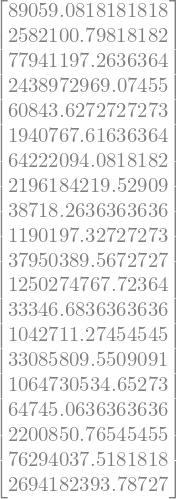

In [117]:
DiffMatrixb

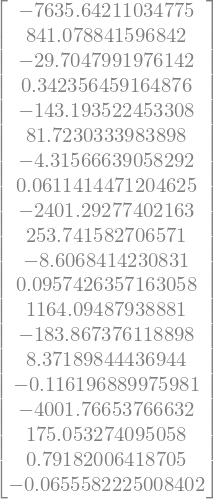

In [124]:
results = DiffMatrixA.inv()*DiffMatrixb
results

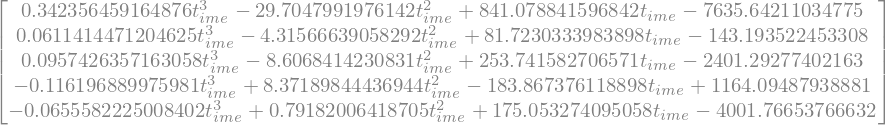

In [158]:
wExpr = results.reshape(n, k+1)*ts
wExpr

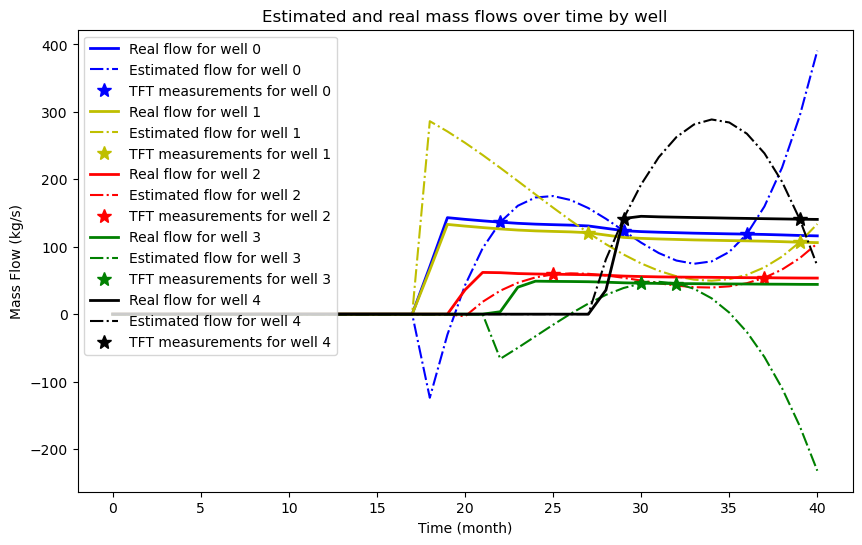

In [159]:
# Plot results from all wells
plt.figure(figsize=(10,6))
colours=['b', 'y', 'r', 'g', 'k']
for i in range(n):
    plt.plot(range(T),mReal[i,:][:], colours[i]+'-', lw=2, label="Real flow for well "+str(i))
    # Plot Time-Dependently
    toplot = []
    for t in range(T):
        resplot = wExpr[i].subs(time, t)
        toplot.append(resplot*zReal[i,t])
    plt.plot(range(T),toplot, colours[i]+'-.', lw=1.5, label="Estimated flow for well "+str(i))
    # Plot TFT points
    monthplot = []
    tftplot = []
    for month,element in enumerate(dReal[i,:]):
        if element==1:
            monthplot.append(month)
            tftplot.append(mReal[i,month])
    plt.plot(monthplot, tftplot, colours[i]+'*', markersize=10, label="TFT measurements for well "+str(i))
            
plt.title("Estimated and real mass flows over time by well")
plt.xlabel("Time (month)")
plt.ylabel("Mass Flow (kg/s)")
plt.legend()


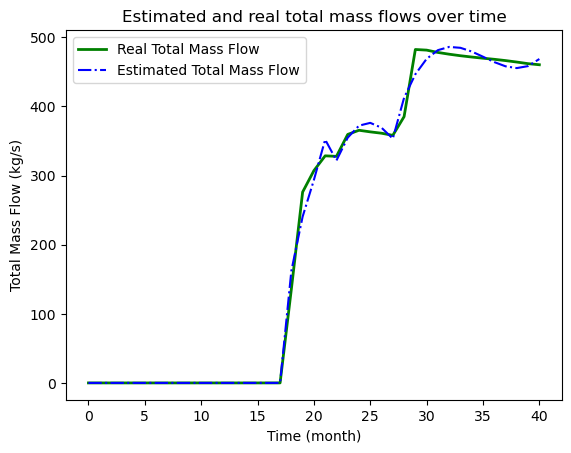

In [160]:
# Plot total flow vs found total flow
totalFlowFound = np.zeros((T,1))
times = range(T)
for t in range(T):
    tff = [wExpr[i].subs(time, t)*zReal[i,t] for i in range(n)]
    #print(t, tff)
    totalFlowFound[t] = sum(tff)

plt.plot(list(Matrix(times).T), list(MReal), 'g-', lw=2, label="Real Total Mass Flow")
plt.plot(times,totalFlowFound, 'b-.', lw=1.5, label="Estimated Total Mass Flow")

plt.title("Estimated and real total mass flows over time")
plt.xlabel("Time (month)")
plt.ylabel("Total Mass Flow (kg/s)")
plt.legend()